# Proyecto Final de Machine Learning - Dataset SUPPORT2

## Proyecto en Grupo

Este notebook contiene el preprocesamiento, análisis exploratorio y modelado predictivo del dataset SUPPORT2 obtenido del repositorio UCI Machine Learning Repository.

### Objetivos
- Explorar y comprender el dataset
- Analizar valores faltantes, correlaciones, distribuciones y outliers
- Preprocesar los datos
- Entrenar y evaluar modelos predictivos
- Comparar interpretabilidad y rendimiento de los modelos

### Fuente del Dataset
https://archive.ics.uci.edu/dataset/880/support2


# 1. Carga del Dataset y las librerías

In [29]:
from ucimlrepo import fetch_ucirepo 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro, normaltest
from scipy import stats
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [30]:
# fetch dataset 
support2 = fetch_ucirepo(id=880) 
  
# data (as pandas dataframes) 
X_raw = support2.data.features 
y_raw = support2.data.targets 
  
df = pd.concat([X_raw, y_raw], axis=1)

# metadata 
print(support2.metadata) 
  
# variable information 
print(support2.variables) 

{'uci_id': 880, 'name': 'SUPPORT2', 'repository_url': 'https://archive.ics.uci.edu/dataset/880/support2', 'data_url': 'https://archive.ics.uci.edu/static/public/880/data.csv', 'abstract': "This dataset comprises 9105 individual critically ill patients across 5 United States medical centers, accessioned throughout 1989-1991 and 1992-1994.\nEach row concerns hospitalized patient records who met the inclusion and exclusion criteria for nine disease categories: acute respiratory failure, chronic obstructive pulmonary disease, congestive heart failure, liver disease, coma, colon cancer, lung cancer, multiple organ system failure with malignancy, and multiple organ system failure with sepsis. The goal is to determine these patients' 2- and 6-month survival rates based on several physiologic, demographics, and disease severity information. \nIt is an important problem because it addresses the growing national concern over patients' loss of control near the end of life. It enables earlier deci

# 2. Exploración Inicial del Dataset

In [31]:
# Verificar la estructura
print(f"Forma del dataset: {df.shape}")
# Ver las primeras filas
print(f"Primeras líneas del dataset:  {df.head()}")
print(f"Información del dataser {df.info()}")

Forma del dataset: (9105, 45)
Primeras líneas del dataset:          age     sex            dzgroup             dzclass  num.co   edu  \
0  62.84998    male        Lung Cancer              Cancer       0  11.0   
1  60.33899  female          Cirrhosis  COPD/CHF/Cirrhosis       2  12.0   
2  52.74698  female          Cirrhosis  COPD/CHF/Cirrhosis       2  12.0   
3  42.38498  female        Lung Cancer              Cancer       2  11.0   
4  79.88495  female  ARF/MOSF w/Sepsis            ARF/MOSF       1   NaN   

       income  scoma  charges  totcst  ...        ph  glucose bun  urine  \
0    $11-$25k    0.0   9715.0     NaN  ...  7.459961      NaN NaN    NaN   
1    $11-$25k   44.0  34496.0     NaN  ...  7.250000      NaN NaN    NaN   
2  under $11k    0.0  41094.0     NaN  ...  7.459961      NaN NaN    NaN   
3  under $11k    0.0   3075.0     NaN  ...       NaN      NaN NaN    NaN   
4         NaN   26.0  50127.0     NaN  ...  7.509766      NaN NaN    NaN   

   adlp  adls  adlsc  deat

# 3. Limpieza y preparación del dataset

Para el tratamiento de valores faltantes se aplicaron distintas estrategias según el tipo de variable. En las variables numéricas se utilizaron medidas estadísticas como la media o la mediana para imputar los datos ausentes, mientras que en las variables categóricas se empleó la moda o la categoría más frecuente.

La etapa de preprocesamiento incluye:
- Tratamiento de valores faltantes
- Separación de variables categóricas y numéricas
- Limpieza del dataset
- Preparación de los datos para modelos de machine learning

Tenemos un dataset médico y estamos tratando de predecir si un paciente muere o sobrevive, por lo que necesitamos generar un Índice de Gravedad Sintético basado en Evidencia Clínica (MELD, Criterios de Berlín, etc.)

Usamos herramientas de búsqueda bibliográfica para identificar los biomarcadores con mayor peso pronóstico según la patología. Por ejemplo, para fallos respiratorios aplicamos el ratio de oxigenación de los Criterios de Berlín, y para pacientes con cáncer usamos el índice de comorbilidad y la albúmina como marcador de caquexia, tal como sugieren los papers de medicina paliativa que consultamos.

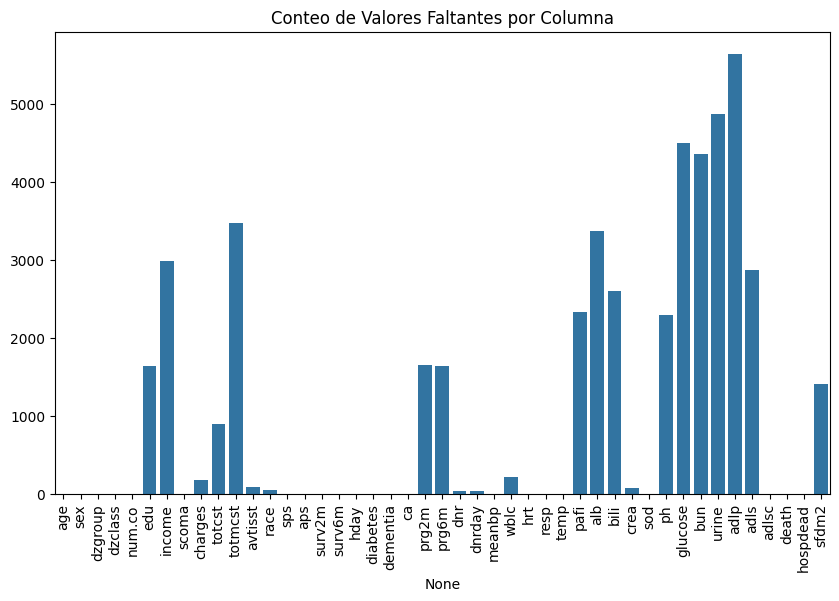

Verificación post-limpieza
Total de valores nulos restantes: 0
Calculando scores...

--- RESUMEN POR ESTADO ---
estado_clinico
Crítico     72.881356
Estable     68.610747
Grave       67.916946
Moderado    67.928954
Name: death, dtype: float64


,age,sex,dzgroup,dzclass,num.co,edu,income,scoma,charges,totcst,...,urine,adlp,adls,adlsc,death,hospdead,sfdm2,gravedad_score,referencia_clinica,estado_clinico
0,62.84998,male,Lung Cancer,Cancer,0,11.000000,$11-$25k,0.0,9715.0,30825.867768,...,2191.546047,7.00000,7.0,7.0,0,0,<2 mo. follow-up,50.0,Criterios Berlín/Sepsis,Moderado
1,60.33899,female,Cirrhosis,COPD/CHF/Cirrhosis,2,12.000000,$11-$25k,44.0,34496.0,30825.867768,...,2191.546047,1.15791,1.0,1.0,1,1,<2 mo. follow-up,30.0,MELD/Child-Pugh (Bili/Crea),Moderado
2,52.74698,female,Cirrhosis,COPD/CHF/Cirrhosis,2,12.000000,under $11k,0.0,41094.0,30825.867768,...,2191.546047,1.00000,0.0,0.0,1,0,<2 mo. follow-up,30.0,MELD/Child-Pugh (Bili/Crea),Moderado
3,42.38498,female,Lung Cancer,Cancer,2,11.000000,under $11k,0.0,3075.0,30825.867768,...,2191.546047,0.00000,0.0,0.0,1,0,no(M2 and SIP pres),50.0,Criterios Berlín/Sepsis,Moderado
4,79.88495,female,ARF/MOSF w/Sepsis,ARF/MOSF,1,11.747691,under $11k,26.0,50127.0,30825.867768,...,2191.546047,1.15791,2.0,2.0,0,0,no(M2 and SIP pres),50.0,Criterios Berlín/Sepsis,Moderado


In [32]:
# 1. Limpieza inicial de nombres de columnas (quitar espacios y poner en minúsculas)
df.columns = [c.lower().strip() for c in df.columns]

# 2. Visualización de valores faltantes
# Visualización de nulos
plt.figure(figsize=(10, 6))
sns.barplot(x=df.isnull().sum().index, y=df.isnull().sum().values)
plt.xticks(rotation=90)
plt.title("Conteo de Valores Faltantes por Columna")
plt.show()


# 3. LIMPIEZA DE VALORES NUMÉRICOS: Sustitución por la Media
# Requisito: Preprocesamiento de datos y tratamiento de missing values 
num_cols = df.select_dtypes(include=[np.number]).columns
cat_cols = df.select_dtypes(include=['object', 'category']).columns

for col in num_cols:
    if df[col].isnull().sum() > 0:
        mean_val = df[col].mean()
        df[col] = df[col].fillna(mean_val)

# 4. LIMPIEZA DE VALORES CATEGÓRICOS: Sustitución por la Moda
# Requisito: Identificación y tratamiento de missing values 
for col in cat_cols:
    if df[col].isnull().sum() > 0:
        mode_val = df[col].mode()[0]
        df[col] = df[col].fillna(mode_val)

# 5. Verificación final
print("Verificación post-limpieza")
print(f"Total de valores nulos restantes: {df.isnull().sum().sum()}")

# 6. FUNCIÓN DE AYUDA PARA ENCONTRAR COLUMNAS (Evita el KeyError)
def get_val(row, possible_names, default=0):
    for name in possible_names:
        if name in row.index:
            return row[name]
    return default

# 7. LÓGICA BASADA EN PAPERS
def calcular_gravedad_evidencia(row):
    score = 0
    # Buscamos el grupo de diagnóstico
    dz = str(get_val(row, ['dzgroup', 'dz_group', 'group'], 'Unknown'))
    ref = "Criterio General"

    # A. CIRROSIS (Bili, Crea, Alb)
    if 'Cirrhosis' in dz:
        if get_val(row, ['bili']) > 3: score += 40
        if get_val(row, ['crea']) > 1.5: score += 30
        if get_val(row, ['alb']) < 2.5: score += 30
        ref = "MELD/Child-Pugh (Bili/Crea)"

    # B. CARDÍACO (MeanBP, Crea, Age)
    elif 'CHF' in dz:
        if get_val(row, ['meanbp']) < 60: score += 40
        if get_val(row, ['crea']) > 2.0: score += 30
        if get_val(row, ['age']) > 75: score += 30
        ref = "Factores Pronósticos CHF"

    # C. RESPIRATORIO (PaO2, FiO2, PH, Temp)
    elif any(x in dz for x in ['COPD', 'Lung', 'ARF']):
        pao2 = get_val(row, ['pao2'])
        fio2 = get_val(row, ['fio2', 'fi.o2']) # Buscamos con punto o sin punto
        
        # Si no hay fio2, usamos 0.21 (aire ambiente)
        fio2_val = fio2 if fio2 > 0 else 0.21
        if fio2_val > 1: fio2_val = fio2_val / 100
        
        ratio = pao2 / fio2_val
        if ratio < 200: score += 50
        if get_val(row, ['ph']) < 7.35: score += 30
        if get_val(row, ['temp']) > 39: score += 20
        ref = "Criterios Berlín/Sepsis"

    # D. COMA
    elif 'Coma' in dz:
        aps = get_val(row, ['aps'])
        score = (aps / 140) * 70
        if get_val(row, ['meanbp']) < 60: score += 30
        ref = "Neurología GCS/APS"

    # E. OTROS / CÁNCER
    else:
        if get_val(row, ['alb']) < 3.0: score += 40
        # Comorbilidades
        num_co = get_val(row, ['num.co', 'num_co', 'nco'], 0)
        if num_co >= 3: score += 30
        score += (get_val(row, ['aps']) * 0.2)
        ref = "Ajuste Comorbilidad"

    return pd.Series([min(score, 100), ref])

print("Calculando scores...")
# Aplicamos la función con expand para crear las dos columnas
df[['gravedad_score', 'referencia_clinica']] = df.apply(calcular_gravedad_evidencia, axis=1)

# 8. CLASIFICACIÓN
def clasificar(s):
    if s < 30: return 'Estable'
    elif s < 60: return 'Moderado'
    elif s < 85: return 'Grave'
    else: return 'Crítico'

df['estado_clinico'] = df['gravedad_score'].apply(clasificar)

# 9. VALIDACIÓN Y GUARDADO
print("\n--- RESUMEN POR ESTADO ---")
if 'death' in df.columns:
    print(df.groupby('estado_clinico')['death'].mean() * 100)

df.to_csv('dataset_final_corregido.csv', index=False)
df.head()

# 4. Análisis Exploratorio de Datos (EDA)

Esta sección incluye:
- Distribución de variables
- Análisis de normalidad
- Correlaciones
- Detección de outliers
- Exploración visual del dataset



--- Resumen Estadístico ---
               age       num.co          edu        scoma       charges  \
count  9105.000000  9105.000000  9105.000000  9105.000000  9.105000e+03   
mean     62.650823     1.868644    11.747691    12.058546  5.999579e+04   
std      15.593710     1.344409     3.123051    24.635341  1.016745e+05   
min      18.041990     0.000000     0.000000     0.000000  1.169000e+03   
25%      52.797000     1.000000    11.000000     0.000000  9.941000e+03   
50%      64.856990     2.000000    12.000000     0.000000  2.580400e+04   
75%      73.998960     3.000000    12.000000     9.000000  6.353100e+04   
max     101.847960     9.000000    31.000000   100.000000  1.435423e+06   

              totcst        totmcst      avtisst          sps          aps  \
count    9105.000000    9105.000000  9105.000000  9105.000000  9105.000000   
mean    30825.867768   28828.877838    22.610928    25.525872    37.597979   
std     43490.827130   34286.917275    13.173517     9.898833

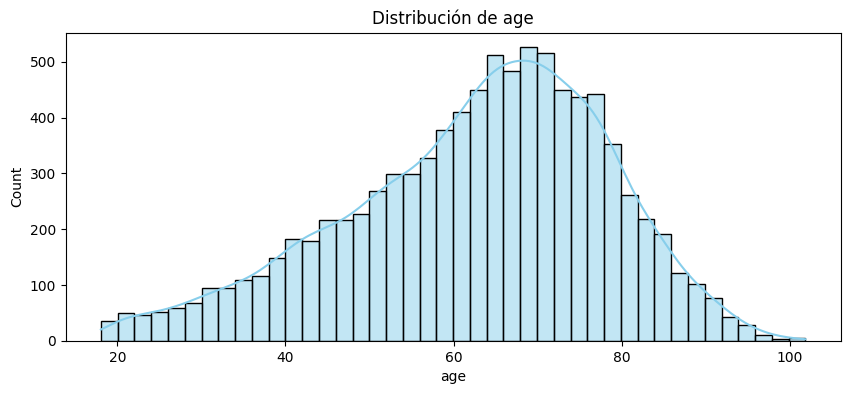

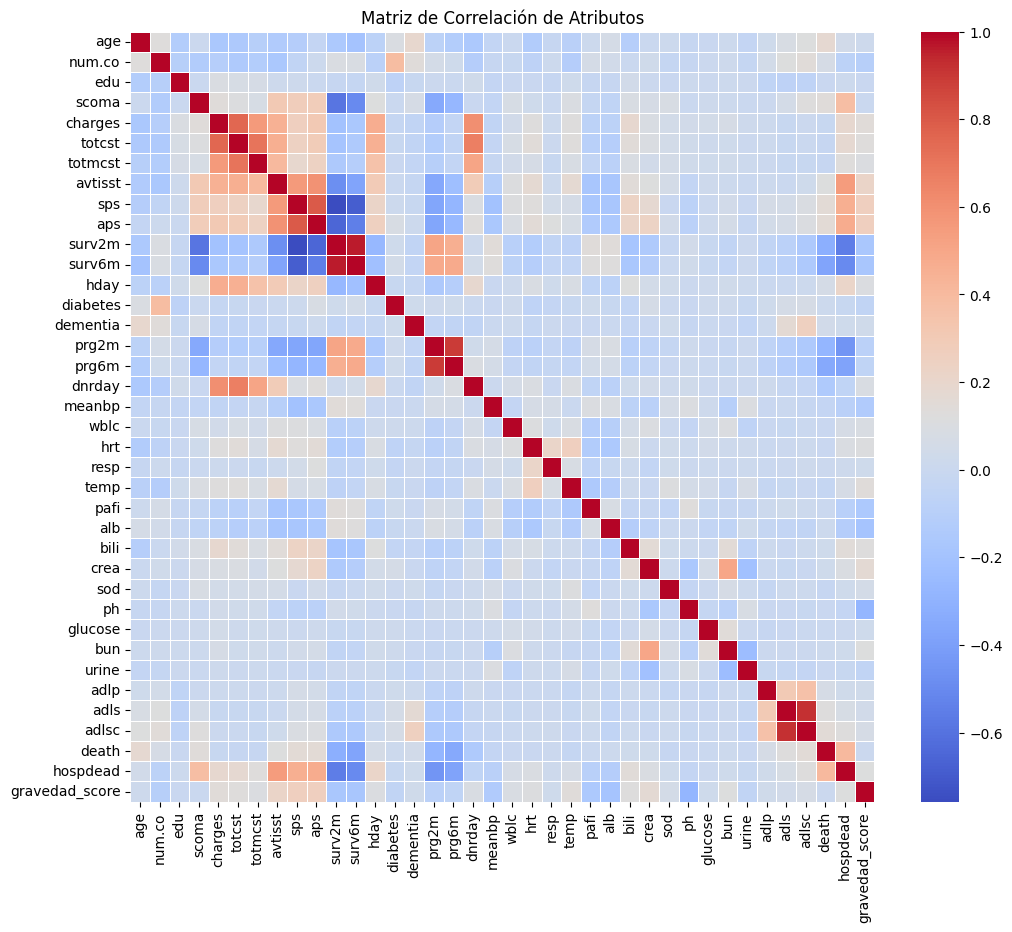

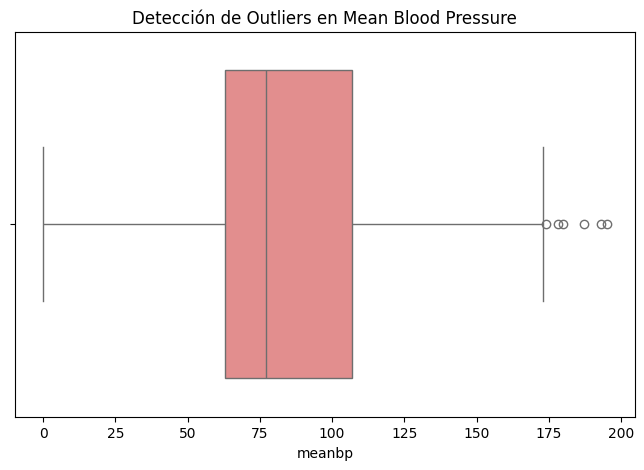

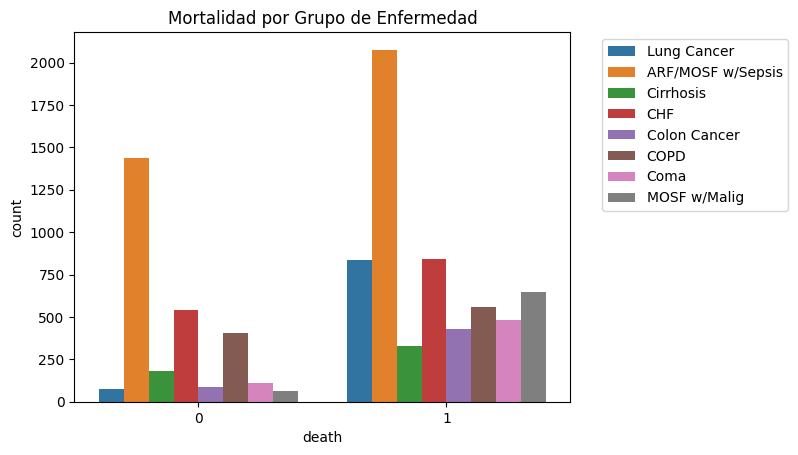

In [33]:
# 1. ESTADÍSTICA DESCRIPTIVA 
# Calculamos medias, desviaciones, etc. para variables numéricas
print("\n--- Resumen Estadístico ---")
stats_desc = df.describe()
print(stats_desc)

# 2. EVALUACIÓN DE NORMALIDAD 
# Vamos a analizar una variable clave, por ejemplo 'age' o 'temp'
variable_test = 'age' 
print(f"\n--- Test de Normalidad para {variable_test} ---")
stat, p = normaltest(df[variable_test].dropna())
print(f'Estadístico={stat:.3f}, p-value={p:.3f}')
if p > 0.05:
    print("La muestra parece seguir una distribución normal (No se rechaza H0)")
else:
    print("La muestra NO sigue una distribución normal (Se rechaza H0)")

# 3. Visualización de la distribución
plt.figure(figsize=(10, 4))
sns.histplot(df[variable_test].dropna(), kde=True, color='skyblue')
plt.title(f'Distribución de {variable_test}')
plt.show()

# 4. CORRELACIONES 
plt.figure(figsize=(12, 10))
# Seleccionamos solo las numéricas para la matriz
corr_matrix = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title("Matriz de Correlación de Atributos")
plt.show()

# 5. IDENTIFICACIÓN DE OUTLIERS 
# Usamos un Boxplot para ver valores atípicos en la presión arterial media (meanbp)
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['meanbp'], color='lightcoral')
plt.title("Detección de Outliers en Mean Blood Pressure")
plt.show()

# 6. ANÁLISIS DE INFORMACIÓN (Visual exploration) 
sns.countplot(x='death', hue='dzgroup', data=df)
plt.title("Mortalidad por Grupo de Enfermedad")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

--- ESTADÍSTICOS DESCRIPTIVOS ---
                            mean        median            std        min  \
age                    62.650823     64.856990       15.59371   18.04199   
sex                          NaN           NaN            NaN        NaN   
dzgroup                      NaN           NaN            NaN        NaN   
dzclass                      NaN           NaN            NaN        NaN   
num.co                  1.868644      2.000000       1.344409        0.0   
edu                    11.747691     12.000000       3.123051        0.0   
income                       NaN           NaN            NaN        NaN   
scoma                  12.058546      0.000000      24.635341        0.0   
charges             59995.787811  25804.000000  101674.493385     1169.0   
totcst              30825.867768  17302.796900    43490.82713        0.0   
totmcst             28828.877838  28828.877838   34286.917275 -102.71997   
avtisst                22.610928     19.750000      13

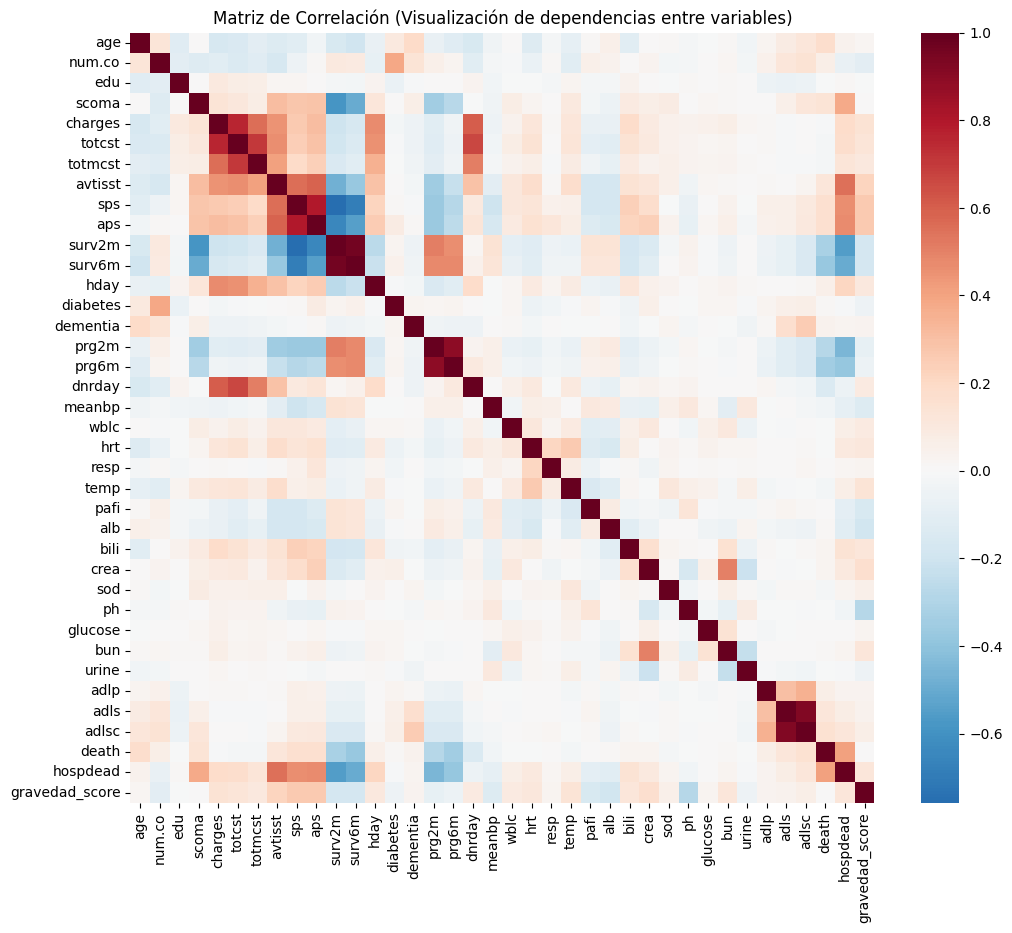

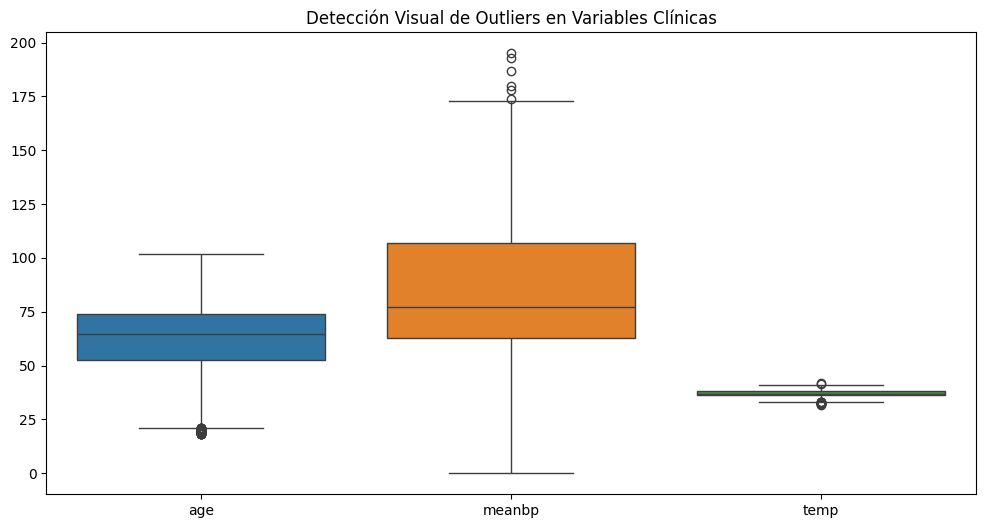

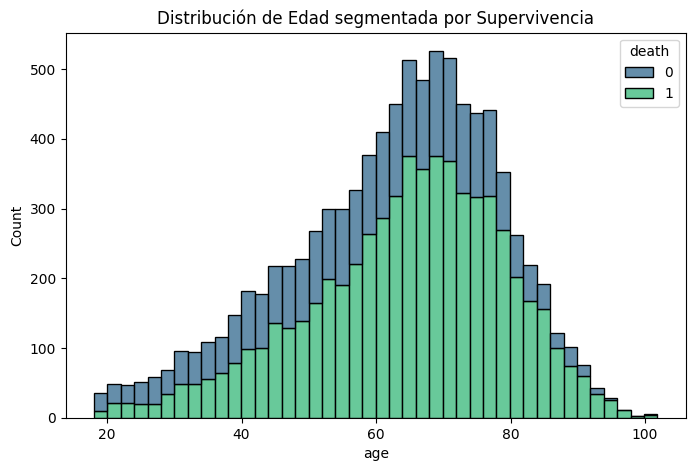

['Lung Cancer' 'Cirrhosis' 'ARF/MOSF w/Sepsis' 'Coma' 'CHF' 'Colon Cancer'
 'COPD' 'MOSF w/Malig']
Hay 8 enfermedades distintas.
dzgroup
ARF/MOSF w/Sepsis    3515
CHF                  1387
COPD                  967
Lung Cancer           908
MOSF w/Malig          712
Coma                  596
Colon Cancer          512
Cirrhosis             508
Name: count, dtype: int64


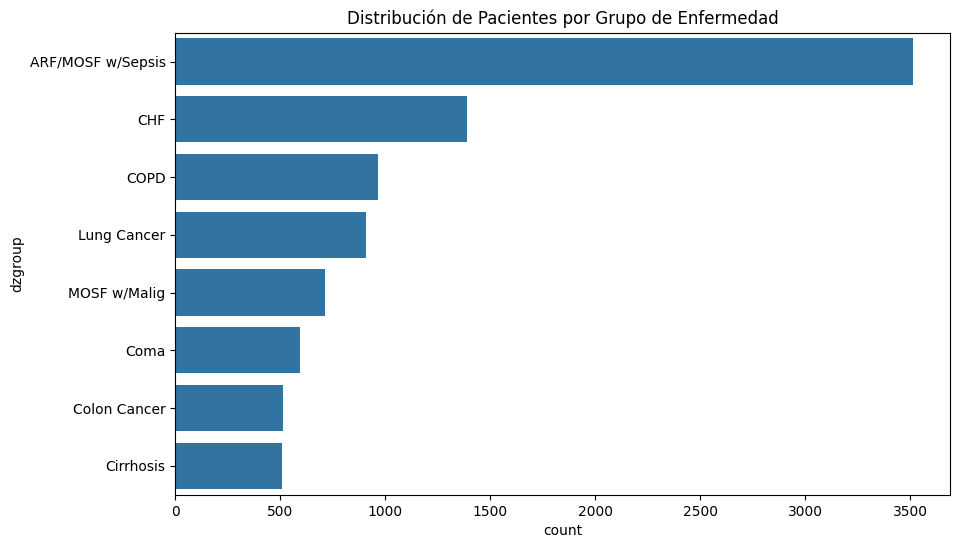

In [34]:
# 1. ESTADÍSTICA DESCRIPTIVA (Requisito: "calculation of descriptive statistical values")
print("--- ESTADÍSTICOS DESCRIPTIVOS ---")
desc_stats = df.describe(include='all').T
# Añadimos la mediana explícitamente ya que es clave para la interpretación
desc_stats['median'] = df.median(numeric_only=True)
print(desc_stats[['mean', 'median', 'std', 'min', 'max']])

# 2. EVALUACIÓN DE NORMALIDAD (Requisito: "assessment of feature normality")
# Analizamos variables críticas como edad y presión arterial
def check_normality(data, column_name):
    # Eliminamos nulos para el test
    clean_data = data[column_name]
    # Test de Shapiro-Wilk (si N < 5000) o D'Agostino (si N es grande)
    stat, p = stats.normaltest(clean_data) 
    print(f"\nColumna: {column_name}")
    print(f"p-value del test de normalidad: {p:.4f}")
    if p < 0.05:
        print("Resultado: Los datos NO siguen una distribución normal (Rechazamos H0)")
    else:
        print("Resultado: Los datos SIGUEN una distribución normal (No rechazamos H0)")

variables_clinicas = ['age', 'meanbp', 'temp', 'crea']
for var in variables_clinicas:
    check_normality(df, var)

# 4. CORRELACIONES (Requisito: "feature correlations")
plt.figure(figsize=(12, 10))
correlation_matrix = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(correlation_matrix, annot=False, cmap='RdBu_r', center=0)
plt.title("Matriz de Correlación (Visualización de dependencias entre variables)")
plt.show()

# 5. IDENTIFICACIÓN DE OUTLIERS Y NULOS (Requisito: "identification of outliers and missing values")
# Boxplots para Outliers
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[['age', 'meanbp', 'temp']])
plt.title("Detección Visual de Outliers en Variables Clínicas")
plt.show()

# 6. ANÁLISIS DE INFORMACIÓN (Feature Relevance)
# Ejemplo: ¿Cómo influye la edad en la supervivencia?
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='age', hue='death', multiple="stack", palette='viridis')
plt.title("Distribución de Edad segmentada por Supervivencia")
plt.show()

#7. Análisis del número de enfermedades y visualización de ello
nombres_enfermedades = df['dzgroup'].unique()
print(nombres_enfermedades)
total_enfermedades = df['dzgroup'].nunique()
print(f"Hay {total_enfermedades} enfermedades distintas.")
conteo_por_enfermedad = df['dzgroup'].value_counts()
print(conteo_por_enfermedad)

plt.figure(figsize=(10,6))
sns.countplot(data=df, y='dzgroup', order=df['dzgroup'].value_counts().index)
plt.title('Distribución de Pacientes por Grupo de Enfermedad')
plt.show()

# 5. Tarea Predictiva

El objetivo de este proyecto es predecir resultados de pacientes utilizando variables clínicas del dataset SUPPORT2.

Este es un problema de clasificación supervisada donde los modelos de machine learning se entrenan para predecir la variable objetivo a partir de información de los pacientes.


# 6. Modelo Predictivo - Random Forest

La siguiente sección entrena y evalúa un clasificador Random Forest.

La evaluación incluye:
- Accuracy
- Classification report
- Matriz de confusión
- Análisis de importancia de variables


In [35]:
# 1. Seleccionamos las columnas que son texto (objetos)
categorical_cols = X_raw.select_dtypes(include=['object']).columns
print("Columnas a transformar:", categorical_cols)

# 2. Aplicamos One-Hot Encoding
# Esto convertirá 'sex' en 'sex_male' y 'sex_female' con ceros y unos
X = pd.get_dummies(X_raw, columns=categorical_cols, drop_first=True)

# 3. Importante: El dataset SUPPORT2 tiene muchos nulos (NaN)
# Los modelos de sklearn no aceptan nulos. Vamos a rellenarlos con la mediana
X = X.fillna(X.median())

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Limpieza rápida necesaria para SUPPORT2
# (Asegúrate de que 'death' sea tu y)
y = df['death']
X = df.drop(columns=['death'])

# A) Convertir texto a números
X = pd.get_dummies(X, drop_first=True)

# B) Rellenar huecos vacíos (Imputación)
X = X.fillna(X.median())

# C) Dividir y Entrenar
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train) # <-- ¡Ahora ya no fallará aquí!

print("Modelo entrenado con éxito.")

Columnas a transformar: Index(['sex', 'dzgroup', 'dzclass', 'income', 'race', 'ca', 'dnr'], dtype='object')
Modelo entrenado con éxito.


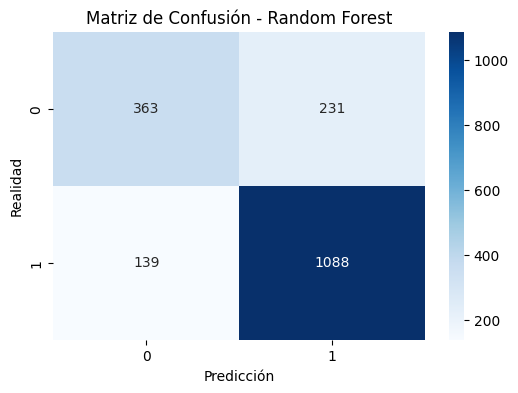

              precision    recall  f1-score   support

           0       0.72      0.61      0.66       594
           1       0.82      0.89      0.85      1227

    accuracy                           0.80      1821
   macro avg       0.77      0.75      0.76      1821
weighted avg       0.79      0.80      0.79      1821



In [36]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Sacamos las predicciones del modelo con los datos de prueba
y_pred = rf_model.predict(X_test)

# Dibujamos la matriz de confusión
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión - Random Forest')
plt.xlabel('Predicción')
plt.ylabel('Realidad')
plt.show()

print(classification_report(y_test, y_pred))

C:\Users\nucla\AppData\Local\Temp\ipykernel_4876\469530884.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Variable', data=df_importancia.head(10), palette='viridis')


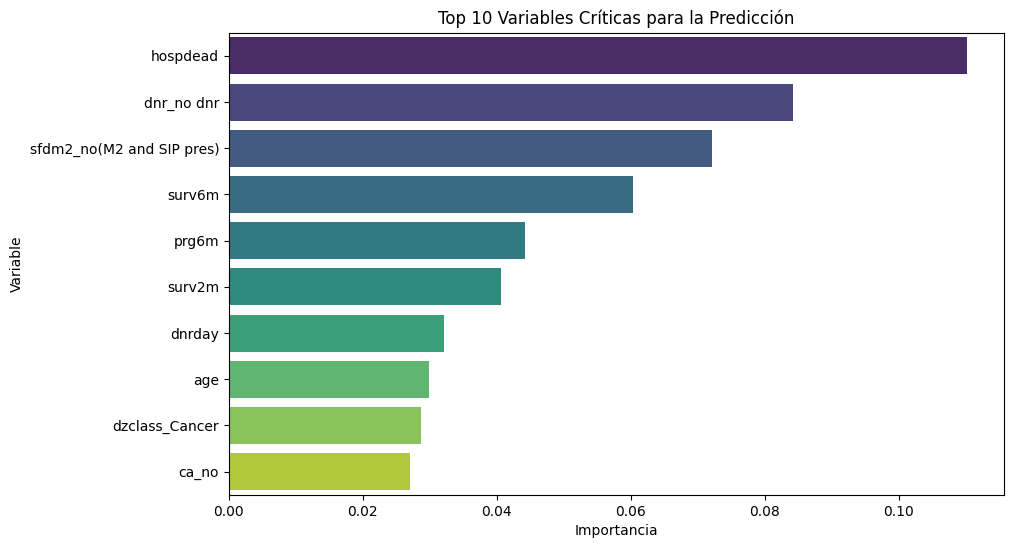

In [37]:
# Obtenemos la importancia de cada columna
importancias = rf_model.feature_importances_
nombres_columnas = X.columns

# Creamos un DataFrame para ordenarlas
df_importancia = pd.DataFrame({'Variable': nombres_columnas, 'Importancia': importancias})
df_importancia = df_importancia.sort_values(by='Importancia', ascending=False)

# Graficamos las 10 más importantes
plt.figure(figsize=(10,6))
sns.barplot(x='Importancia', y='Variable', data=df_importancia.head(10), palette='viridis')
plt.title('Top 10 Variables Críticas para la Predicción')
plt.show()

# 7. Interpretación y Discusión del Modelo

## Interpretabilidad
Los modelos Random Forest son menos interpretables que un árbol de decisión individual, pero permiten analizar la importancia de las variables.

## Accuracy
El valor de accuracy obtenido permite evaluar la capacidad predictiva del modelo.

## Interés
Este tipo de modelo predictivo puede ayudar a identificar pacientes de alto riesgo utilizando variables clínicas.

## Novedad
El proyecto aplica técnicas de machine learning a un dataset médico del mundo real.

## Coste de Aplicación
La mayoría de las variables utilizadas por el modelo provienen de mediciones clínicas estándar, lo que hace que el modelo pueda aplicarse en entornos sanitarios.


# 8. Evaluación Comparativa de Modelos

Aquí pueden añadirse modelos adicionales (Decision Tree, Neural Network, etc.) y compararse según:
- Accuracy
- Interpretability
- Coste computacional
- Utilidad práctica

| Modelo | Accuracy | Interpretabilidad |
|---|---|---|
| Random Forest | Pendiente | Media |
| Decision Tree | Pendiente | Alta |
| Neural Network | Pendiente | Baja |
